In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import joblib


In [2]:
# Load dataset, convert to a dataframe
dataset = load_dataset("aai510-group1/telco-customer-churn")
df = dataset["train"].to_pandas()
print(df.shape)
df.head()

(4225, 52)


,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,...,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,...,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,...,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,...,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,...,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,...,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117


In [3]:
# View all columns
df.columns

Index(['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges',
       'Churn', 'Churn Category', 'Churn Reason', 'Churn Score', 'City',
       'CLTV', 'Contract', 'Country', 'Customer ID', 'Customer Status',
       'Dependents', 'Device Protection Plan', 'Gender', 'Internet Service',
       'Internet Type', 'Lat Long', 'Latitude', 'Longitude', 'Married',
       'Monthly Charge', 'Multiple Lines', 'Number of Dependents',
       'Number of Referrals', 'Offer', 'Online Backup', 'Online Security',
       'Paperless Billing', 'Partner', 'Payment Method', 'Phone Service',
       'Population', 'Premium Tech Support', 'Quarter', 'Referred a Friend',
       'Satisfaction Score', 'Senior Citizen', 'State', 'Streaming Movies',
       'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data',
       'Zip Code'],
      dtype='object')

In [4]:
# Drop variables not used
df = df.drop(["Churn Category", "Churn Reason", "Churn Score", "City", "Country", "Customer ID",
              "Customer Status", "Gender", "Lat Long", "Latitude", "Longitude", "Offer",
              "Quarter", "State", "Zip Code"
             ], axis="columns")
df


,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Contract,Dependents,Device Protection Plan,Internet Service,Internet Type,...,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
0,72,4,19.44,0,4849,Two Year,0,1,1,Fiber Optic,...,1,0,25,2191.15,0,486.00,0.00,2677.15,0,1
1,27,59,45.62,0,3715,Month-to-Month,0,1,1,Fiber Optic,...,0,1,35,3418.20,0,1596.70,0.00,5014.90,1,1
2,59,0,16.07,0,5092,Month-to-Month,0,0,0,None,...,0,0,46,851.20,0,739.22,0.00,1590.42,0,0
3,25,27,0.00,0,2068,One Year,0,1,1,DSL,...,1,0,27,1246.40,30,0.00,0.00,1276.40,1,0
4,31,21,17.22,1,4026,One Year,0,1,1,Cable,...,0,0,58,3563.80,0,998.76,0.00,4562.56,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,36,0,7.76,0,4590,Month-to-Month,0,0,0,None,...,0,0,1,19.90,0,7.76,0.00,27.66,0,0
4221,77,22,23.43,0,5602,One Year,0,0,1,Fiber Optic,...,0,0,22,1820.90,0,515.46,29.88,2306.48,0,1
4222,56,0,28.06,0,4458,One Year,1,0,0,None,...,0,0,18,345.90,0,505.08,0.00,850.98,0,0
4223,45,22,0.00,0,4115,Month-to-Month,0,1,1,Cable,...,1,1,57,3437.45,0,0.00,0.00,3437.45,0,1


In [5]:
# Get dummy variables for String type variables
def getDummies(dFrame):
    return pd.get_dummies(df, columns=["Contract", "Payment Method", "Internet Type"], drop_first=True)

df = getDummies(df)

In [6]:
# Get X variables and y variable and split for training and testing sets
X = df.drop(columns="Churn")
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# Create Model
def create_model(X_train_data, y_train_data, model):
    model.fit(X_train_data, y_train_data)
    return model

def model_metrics(X_test_data, y_test_data, model):
    y_pred = model.predict(X_test_data)
    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)
    return [acc, prec, rec, f1]

In [8]:
# Random Forrest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf_clf = create_model(X_train, y_train, rf_clf)


rf_metrics = model_metrics(X_test, y_test, rf_clf)
print(f"Random Forest Classifier\nAccuracy:\t {rf_metrics[0]}")
print(f"Precision:\t {rf_metrics[1]}")
print(f"Recall:\t\t {rf_metrics[2]}")
print(f"F1:\t\t {rf_metrics[3]}")

Random Forest Classifier
Accuracy:	 0.9680473372781065
Precision:	 0.9758454106280193
Recall:		 0.9017857142857143
F1:		 0.9373549883990719


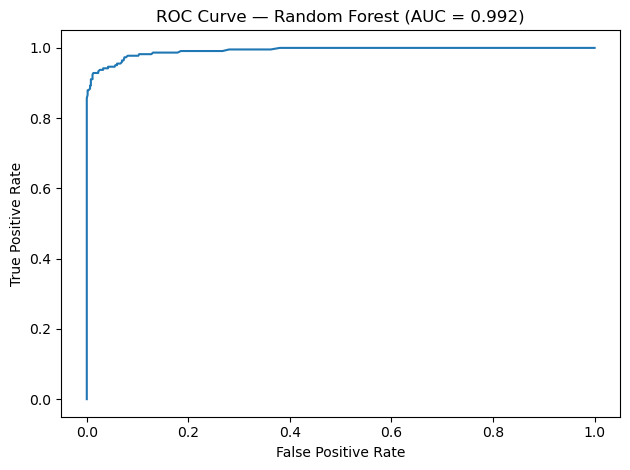

In [9]:
# ROC Curve + AUC
probs = rf_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Random Forest (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()
plt.close()

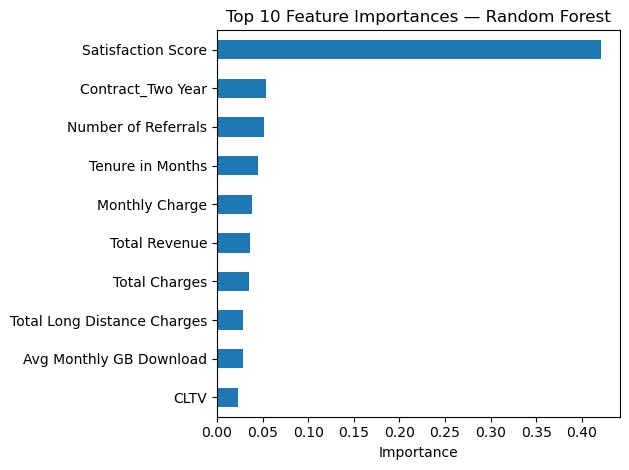

In [10]:
# Feature importance (Top 10)
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = importances.head(10)

plt.figure()
top10.sort_values().plot(kind="barh")  # no custom colors
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()
plt.close()

Confusion Matrix (TN, FP, FN, TP): 616, 5, 22, 202)


Metric,Value
Accuracy,0.968
Precision,0.976
Recall,0.902
F1,0.937
ROC-AUC,0.992


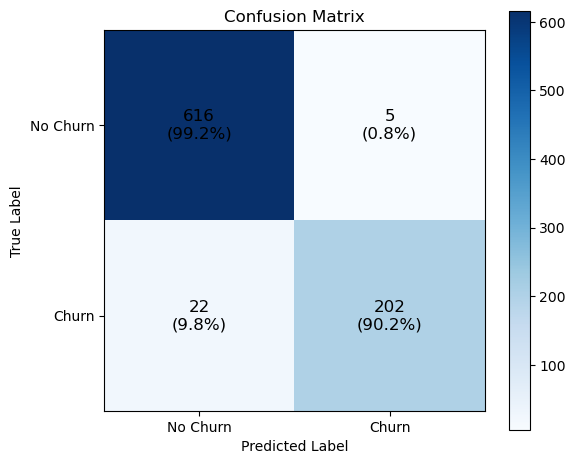

In [11]:
# Confusion matrix + core metrics
y_pred = rf_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

rf_precision = tp / (tp + fp) if (tp + fp) else 0
rf_recall = tp / (tp + fn) if (tp + fn) else 0
rf_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0
rf_f1 = (2 * rf_precision * rf_recall / (rf_precision + rf_recall)) if (rf_precision + rf_recall) else 0

print(f"Confusion Matrix (TN, FP, FN, TP): {tn}, {fp}, {fn}, {tp})")

rf_metrics_df = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
                           "Value": [rf_accuracy, rf_precision, rf_recall,
                                     rf_f1, roc_auc]})

display(rf_metrics_df.style.hide(axis="index").format({"Value": "{:.3f}"}))

# Plot
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0,1], ["No Churn", "Churn"])
plt.yticks([0,1], ["No Churn", "Churn"])

# Annotate with counts + %
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percent = cm[i, j] / cm.sum(axis=1)[i]
        plt.text(j, i,
                 f"{cm[i, j]}\n({percent:.1%})",
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=12)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.colorbar()

plt.tight_layout()
plt.show()


In [12]:
# Logistic Regression Classifier
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

lr_clf = create_model(X_train, y_train, log_pipeline)

lr_metrics = model_metrics(X_test, y_test, lr_clf)

lr_accuracy = lr_metrics[0].round(3)
lr_precision = lr_metrics[1].round(3)
lr_recall = lr_metrics[2].round(3)
lr_f1 = lr_metrics[3].round(3)

print(f"Logistic Regression\nAccuracy:\t {lr_accuracy}")
print(f"Precision:\t {lr_precision}")
print(f"Recall:\t\t {lr_recall}")
print(f"F1:\t\t {lr_f1}")


Logistic Regression
Accuracy:	 0.96
Precision:	 0.94
Recall:		 0.906
F1:		 0.923


In [13]:
# Bernoulli NB
nb_clf = create_model(X_train, y_train, BernoulliNB())
nb_metrics = model_metrics(X_test, y_test, nb_clf)
nb_accuracy = nb_metrics[0].round(3)
nb_precision = nb_metrics[1].round(3)
nb_recall = nb_metrics[2].round(3)
nb_f1 = nb_metrics[3].round(3)
print(f"Naive Bayes Classifier\nAccuracy:\t {nb_accuracy}")
print(f"Precision:\t {nb_precision}")
print(f"Recall:\t\t {nb_recall}")
print(f"F1:\t\t {nb_f1}")

Naive Bayes Classifier
Accuracy:	 0.763
Precision:	 0.543
Recall:		 0.683
F1:		 0.605


In [14]:
metrics_dict = {"Model": ["Bernoulli NB", "Logistic Regression", "Random Forest"],
                "Accuracy": [nb_accuracy, lr_accuracy, rf_accuracy],
                "Precision": [nb_precision, lr_precision, rf_precision],
                "Recall": [nb_recall, lr_recall, rf_recall],
                "F1": [nb_f1, lr_f1, rf_f1]}

metrics_df = pd.DataFrame(metrics_dict)
display(metrics_df.style.hide(axis="index").format({"Accuracy": "{:.3f}",
                                                    "Precision": "{:.3f}",
                                                    "Recall": "{:.3f}",
                                                    "F1": "{:.3f}"}))



Model,Accuracy,Precision,Recall,F1
Bernoulli NB,0.763,0.543,0.683,0.605
Logistic Regression,0.960,0.940,0.906,0.923
Random Forest,0.968,0.976,0.902,0.937


In [15]:
importances = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances_dict = {"Feature": importances.index, "Importance": importances.values}

importances_df = pd.DataFrame(importances_dict)

importances_df.head(10)

display(importances_df.head(10).style.hide(axis="index").format({"Importance": "{:.3f}"}))

Feature,Importance
Satisfaction Score,0.421
Contract_Two Year,0.053
Number of Referrals,0.052
Tenure in Months,0.045
Monthly Charge,0.038
Total Revenue,0.036
Total Charges,0.035
Total Long Distance Charges,0.028
Avg Monthly GB Download,0.028
CLTV,0.023


In [16]:
joblib.dump(rf_clf, "churn_model.joblib")

['churn_model.joblib']